In [2]:
import sys
import warnings
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch

from spd.utils import get_device

warnings.filterwarnings("ignore")

# Add the project root to path so we can import spd modules
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from spd.data_utils import DatasetGeneratedDataLoader, SparseFeatureDataset
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset
from spd.models.component_model import ComponentModel

device = get_device()
print(f"Using device: {device}")
torch.set_grad_enabled(False)

Using device: cuda


## collect coactivation stats

In [3]:
import torch
from jaxtyping import Float, Int
from torch import Tensor
from torch.utils.data import DataLoader
from tqdm import tqdm

from spd.models.component_utils import calc_component_acts, calc_masks
from spd.utils import extract_batch_data


def calc_jaccard_index(co_occurrence_matrix: Tensor, marginal_counts: Tensor) -> Tensor:
    """
    Calculate the Jaccard index for each component based on co-occurrence matrix and marginal counts.
    Jaccard index = |A ∩ B| / |A ∪ B|
    """
    intersection = co_occurrence_matrix
    union = marginal_counts.unsqueeze(0) + marginal_counts.unsqueeze(1) - intersection
    jaccard_index = intersection / union
    jaccard_index[union == 0] = 0.0  # Handle division by zero
    return jaccard_index


@torch.no_grad()
def collect_coactivations(
    comp_model: ComponentModel,
    data_loader: DataLoader[Int[Tensor, "..."]]
    | DataLoader[tuple[Float[Tensor, "..."], Float[Tensor, "..."]]],
    module_groups: list[list[str]],  # e.g., [["layers.0.mlp"], ["layers.1.attn", "layers.1.mlp"]],
    n_samples: int = 10000,  # number of samples to collect for co-activation
    activation_threshold: float = 0.5,  # mask threshold for a component to be considered active
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
) -> dict[str, Any]:
    # 1. Setup phase - FIXED: use comp_model not model
    components = {
        k.removeprefix("components.").replace("-", "."): v for k, v in comp_model.components.items()
    }
    gates = {k.removeprefix("gates.").replace("-", "."): v for k, v in comp_model.gates.items()}

    # Build module_slices for each group
    results = {}
    for group_idx, modules in enumerate(module_groups):
        # Calculate total components and slices within group
        group_total_m = sum(
            components[mod].m for mod in modules
        )  # FIXED: no need to convert, already dots
        co_matrix = torch.zeros(group_total_m, group_total_m, device=device)
        marginals = torch.zeros(group_total_m, device=device)

        # Build slice mapping
        module_slices = {}
        start_idx = 0
        labels = []
        for mod in modules:
            m = components[mod].m  # FIXED: use mod directly
            module_slices[mod] = slice(start_idx, start_idx + m)
            start_idx += m
            labels += [mod] * m  # Create labels for each component in the module

        results[f"group_{group_idx}"] = {
            "co_occurrence_matrix": co_matrix,
            "marginal_counts": marginals,
            "module_slices": module_slices,
            "modules": modules,
            "labels": np.array(labels),  # Store labels for each component in the group
        }
    # Data processing loop - exact same pattern as optimize()
    samples_processed = 0
    data_iter = iter(data_loader)

    with tqdm(total=n_samples, desc="Collecting coactivations", unit="samples") as pbar:
        while samples_processed < n_samples:
            try:
                batch_item = next(data_iter)
                batch = extract_batch_data(batch_item)
            except StopIteration:
                data_iter = iter(data_loader)
                batch_item = next(data_iter)
                batch = extract_batch_data(batch_item)
            batch = batch.to(device)

            target_out, pre_weight_acts = comp_model.forward_with_pre_forward_cache_hooks(
                batch, module_names=list(gates.keys())
            )
            As = {
                module_name: components[module_name].A  # FIXED: use module_name directly
                for module_name in pre_weight_acts.keys()
            }

            target_component_acts = calc_component_acts(pre_weight_acts=pre_weight_acts, As=As)

            masks, _ = calc_masks(
                gates=gates, target_component_acts=target_component_acts, detach_inputs=True
            )

            # Process each group
            for group_idx, modules in enumerate(module_groups):
                # Concatenate masks within group
                group_masks = torch.cat([masks[mod] for mod in modules], dim=-1)  # [batch, group_m]

                # Apply threshold
                active_mask = group_masks > activation_threshold  # [batch, group_m]

                # Accumulate co-occurrences and marginals
                results[f"group_{group_idx}"]["co_occurrence_matrix"] += torch.einsum(
                    "bi,bj->ij", active_mask.float(), active_mask.float()
                )
                results[f"group_{group_idx}"]["marginal_counts"] += active_mask.sum(dim=0)
            batch_size = batch.size(0)
            samples_processed += batch_size
            pbar.update(batch_size)
    # Add metadata.additoinal_metrics
    for group_key in results:
        results[group_key]["total_samples"] = samples_processed
        results[group_key]["activation_threshold"] = activation_threshold
        results[group_key]["jaccard"] = calc_jaccard_index(
            results[group_key]["co_occurrence_matrix"], results[group_key]["marginal_counts"]
        )

    return results

# plotting helpers

In [4]:
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform


def plot_hierarchical_clustering(
    similarity_matrix,
    labels=None,
    threshold=0.5,
    criterion="distance",
    linkage_method="average",
    figsize=(12, 6),
    cmap="tab20",
    title=None,
):
    """
    Create a hierarchical clustering dendrogram with optional ground truth labels.

    Parameters
    ----------
    similarity_matrix : array-like
        Square similarity matrix (e.g., Jaccard similarity)
    labels : array-like, optional
        Ground truth labels for each element. If provided, shows color bar
    threshold : float, default=0.5
        Distance threshold for clustering (1 - similarity)
    linkage_method : str, default='average'
        Linkage method: 'single', 'complete', 'average', 'ward'
    figsize : tuple, default=(12, 6)
        Figure size (width, height)
    cmap : str, default='tab20'
        Colormap for label categories
    title : str, optional
        Plot title

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object
    clusters : array
        Cluster assignments for each element
    Z : array
        The hierarchical clustering linkage matrix
    """
    # Convert similarity to distance
    distance_matrix = 1 - similarity_matrix
    condensed_dist = squareform(distance_matrix)

    # Perform hierarchical clustering
    Z = linkage(condensed_dist, method=linkage_method)

    # Get clusters
    clusters = fcluster(Z, t=threshold, criterion=criterion)

    # Create figure
    if labels is not None:
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=figsize, gridspec_kw={"height_ratios": [20, 1]}
        )
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=figsize)

    # Plot dendrogram
    dend = dendrogram(
        Z, ax=ax1, color_threshold=threshold if criterion == "distance" else None, no_labels=True
    )
    ax1.axhline(
        y=threshold if criterion == "distance" else 0,
        color="r",
        linestyle="--",
        label=f"{criterion}={threshold}",
    )
    ax1.set_ylabel("Distance (1 - Jaccard Similarity)")
    ax1.legend()

    if title:
        ax1.set_title(title)
    else:
        ax1.set_title(f"Hierarchical Clustering ({linkage_method} linkage)")

    # Add color bar if labels provided
    if labels is not None:
        # Get leaf order and create color mapping
        leaves_order = dend["leaves"]
        ordered_labels = [labels[i] for i in leaves_order]
        unique_labels = list(np.unique(labels))
        label_to_idx = {label: i for i, label in enumerate(unique_labels)}
        color_indices = [label_to_idx[label] for label in ordered_labels]

        # Plot color bar
        ax2.imshow([color_indices], aspect="auto", cmap=cmap)
        ax2.set_xlabel("Subcomponent Module")
        ax2.set_xticks([])
        ax2.set_yticks([])

        # Create legend
        n_colors = len(unique_labels)
        if n_colors <= 20:
            colors = plt.cm.get_cmap(cmap)(np.linspace(0, 1, n_colors))
        else:
            colors = plt.cm.get_cmap("hsv")(np.linspace(0, 0.9, n_colors))

        patches = [
            Patch(color=colors[i], label=str(label)) for i, label in enumerate(unique_labels)
        ]

        # Position legend
        ncol = min(5, n_colors)  # Limit number of columns in legend
        ax2.legend(handles=patches, loc="center", ncol=ncol, bbox_to_anchor=(0.5, -2))

    plt.tight_layout()

    return fig, clusters, Z


def plot_clustering_from_results(
    results,
    group_key="group_2",
    threshold=0.9,
    linkage_method="average",
    min_alive_counts=0,
    **kwargs,
):
    """
    Convenience function to plot directly from results dictionary.

    Parameters
    ----------
    results : dict
        Results dictionary containing 'jaccard', 'marginal_counts', and 'labels'
    group_key : str, default='group_2'
        Which group to analyze
    threshold : float, default=0.9
        Distance threshold for clustering
    linkage_method : str, default='average'
        Linkage method
    **kwargs : additional arguments passed to plot_hierarchical_clustering

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object
    clusters : array
        Cluster assignments for alive elements
    Z : array
        The hierarchical clustering linkage matrix
    alive_mask : array
        Boolean mask of alive elements
    """
    # Extract data
    jaccard_similarity = results[group_key]["jaccard"].cpu().numpy()
    alive_mask = (results[group_key]["marginal_counts"] > min_alive_counts).cpu().numpy()
    ground_truth = results[group_key]["labels"][alive_mask]

    # Mask similarity matrix
    masked_similarity = jaccard_similarity[alive_mask][:, alive_mask]

    # Plot
    fig, clusters, Z = plot_hierarchical_clustering(
        masked_similarity,
        labels=ground_truth,
        threshold=threshold,
        linkage_method=linkage_method,
        **kwargs,
    )

    # Print summary
    print(f"Number of alive elements: {alive_mask.sum()}")
    print(f"Number of clusters: {len(np.unique(clusters))}")
    print(f"Cluster sizes: {np.bincount(clusters)[1:]}")  # Skip 0 if exists

    return fig, clusters, Z, alive_mask

# TMS + identity

In [5]:
MODEL_PATH = "/nlp/scr/nathu/apd/tms/out/randrecon1.00e+00_p1.00e+00_lpsp1.00e-04_m200_sd0_lr1.00e-03_bs4096_gtgate_mlp_ft40_hid10hid-layers1_20250623_163445_149/model_40000.pth"
# Load the decomposition model
comp_model, config, _ = ComponentModel.from_pretrained(MODEL_PATH)
comp_model.to(device)
target_model = comp_model.model


dataset = SparseFeatureDataset(
    n_features=target_model.config.n_features,
    feature_probability=config.task_config.feature_probability,
    device=device,
    data_generation_type=config.task_config.data_generation_type,
    value_range=(0.0, 1.0),
    synced_inputs=None,
)
data_loader = DatasetGeneratedDataLoader(
    dataset=dataset,
    batch_size=1000,
    shuffle=False,
)

In [6]:
results = collect_coactivations(
    comp_model=comp_model,
    data_loader=data_loader,
    module_groups=[["linear1", "linear2", "hidden_layers.0"]],
    n_samples=500000,
    activation_threshold=0.1,
)

Number of alive elements: 90
Number of clusters: 41
Cluster sizes: [ 2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2 10  2  2]


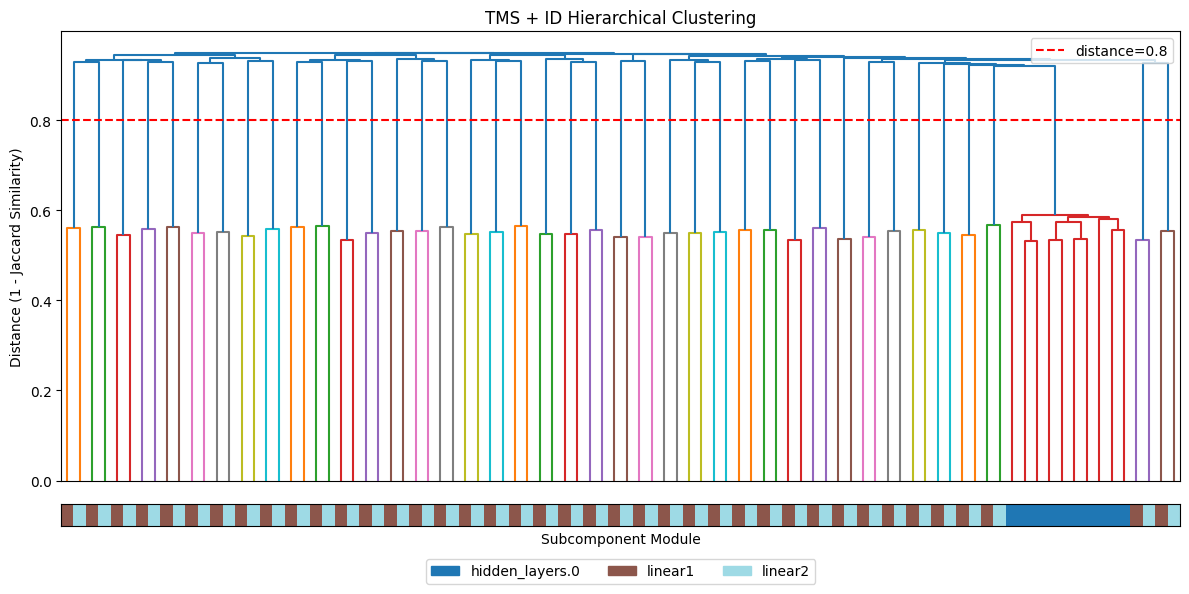

In [15]:
fig, clusters, Z, alive_mask = plot_clustering_from_results(
    results,
    group_key="group_0",
    threshold=0.8,
    title="TMS + ID Hierarchical Clustering",
    min_alive_counts=500,
)

# 1 layer residual MLP

In [240]:
MODEL_PATH = "/afs/cs.stanford.edu/u/nathu/code/apd/spd/experiments/resid_mlp/out/randrecon1.00e+00_p2.00e+00_lpsp1.00e-05_m100_sd1_lr2.00e-03_bs2048_gtgate_mlp_ft100_lay1_resid1000_mlp50_20250618_181826_677/model_30000.pth"
# Load the decomposition model
comp_model, config, _ = ComponentModel.from_pretrained(MODEL_PATH)
comp_model.to(device)
target_model = comp_model.model


dataset = ResidualMLPDataset(
    n_features=target_model.config.n_features,
    feature_probability=config.task_config.feature_probability,
    device=device,
    calc_labels=False,  # Our labels will be the output of the target model
    label_type=None,
    act_fn_name=None,
    label_fn_seed=None,
    label_coeffs=None,
    data_generation_type=config.task_config.data_generation_type,
    synced_inputs=None,
)
data_loader = DatasetGeneratedDataLoader(
    dataset=dataset,
    batch_size=1000,
    shuffle=False,
)

2025-06-23 16:43:30 - INFO - Downloaded checkpoint from /sailhome/nathu/code/apd/wandb/92pa1z14/files/resid_mlp.pth


In [241]:
results = collect_coactivations(
    comp_model=comp_model,
    data_loader=data_loader,
    module_groups=[["layers.0.mlp_in", "layers.0.mlp_out"]],
    n_samples=500000,
    activation_threshold=0.1,
)

Number of alive elements: 150
Number of clusters: 101
Cluster sizes: [50  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1]


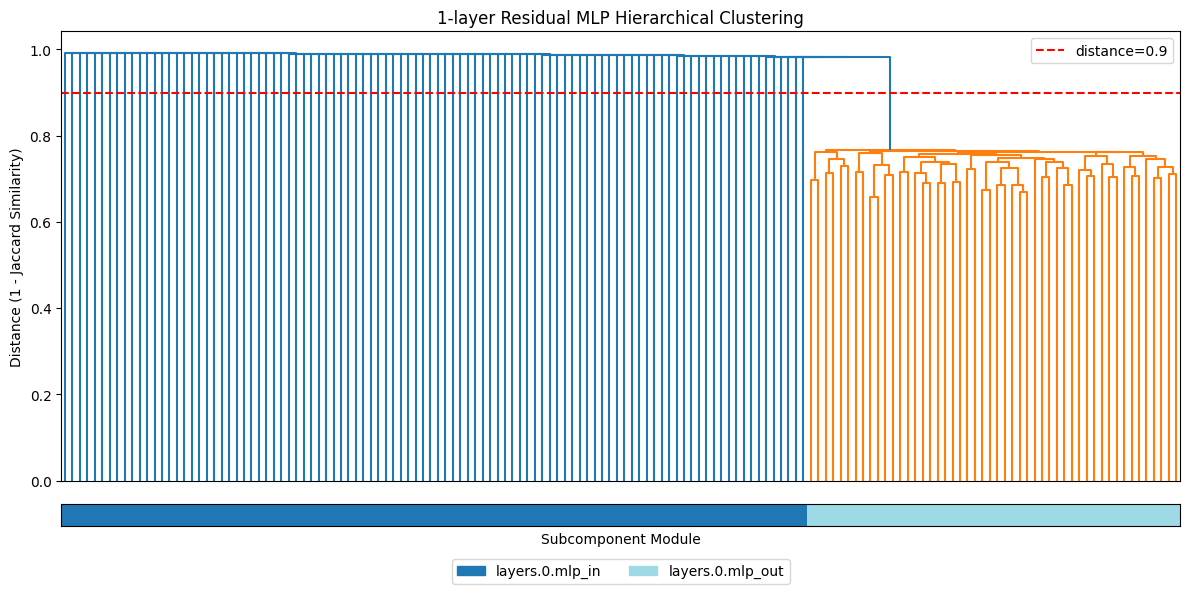

In [242]:
# Quick one-liner with your data
fig, clusters, Z, alive_mask = plot_clustering_from_results(
    results,
    group_key="group_0",
    threshold=0.9,
    title="1-layer Residual MLP Hierarchical Clustering",
    min_alive_counts=500,
)

# 3 layer residual MLP

In [5]:
MODEL_PATH = "/nlp/scr/nathu/apd/resid_mlp/out/randrecon1.00e+00_p2.00e+00_lpsp5.00e-06_m400_sd1_lr1.00e-03_bs2048_gtscaled_sigmoid_gate_mlp_ft102_lay3_resid1000_mlp17_20250620_160724_714/model_120000.pth"
# Load the decomposition model
comp_model, config, _ = ComponentModel.from_pretrained(MODEL_PATH)
comp_model.to(device)
target_model = comp_model.model


dataset = ResidualMLPDataset(
    n_features=target_model.config.n_features,
    feature_probability=config.task_config.feature_probability,
    device=device,
    calc_labels=False,  # Our labels will be the output of the target model
    label_type=None,
    act_fn_name=None,
    label_fn_seed=None,
    label_coeffs=None,
    data_generation_type=config.task_config.data_generation_type,
    synced_inputs=None,
)
data_loader = DatasetGeneratedDataLoader(
    dataset=dataset,
    batch_size=1000,
    shuffle=False,
)

2025-06-23 19:58:16 - INFO - Downloaded checkpoint from /sailhome/nathu/code/apd/wandb/d5azngjz/files/resid_mlp.pth


In [6]:
results = collect_coactivations(
    comp_model=comp_model,
    data_loader=data_loader,
    module_groups=[
        [
            "layers.0.mlp_in",
            "layers.0.mlp_out",
            "layers.1.mlp_in",
            "layers.1.mlp_out",
            "layers.2.mlp_in",
            "layers.2.mlp_out",
        ]
    ],
    n_samples=500000,
    activation_threshold=0.1,
)

Number of alive elements: 405
Number of clusters: 122
Cluster sizes: [ 4  4  4  4  4  4  4  4  4  4  4  4  3  1  4  4  4  4  3  3  1  3  3  1
  4  3  2  3  3  4  3  3  1  4  3  3  3  3  1  3  2  4  3  4  3  1  3  1
  3  1  3  3  2  3  3  4  3  3  3  2  4  3  1  2  3  3  4  1  4  3  3  1
  3  3  3  3  1  3  3  3  3  3  3  1  2  1  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3 51
  3  3]


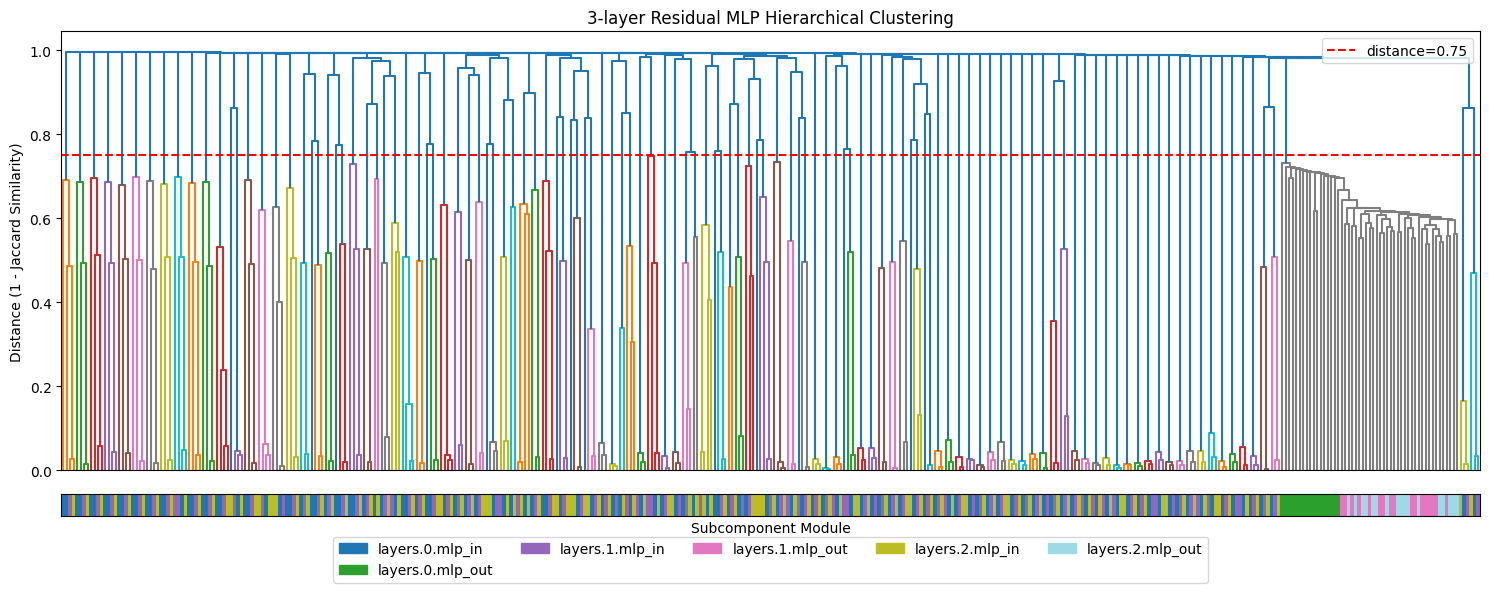

In [8]:
fig, clusters, Z, alive_mask = plot_clustering_from_results(
    results,
    group_key="group_0",
    linkage_method="average",  # complete
    threshold=0.75,
    title="3-layer Residual MLP Hierarchical Clustering",
    min_alive_counts=500,
    figsize=(15, 6),
)

In [11]:
pd.Series(clusters).value_counts().value_counts()

count
3     76
4     25
1     14
2      6
51     1
Name: count, dtype: int64

In [ ]:
import pandas as pd

submodules = results["group_0"]["labels"][alive_mask]
# Get top 10 clusters by size
cluster_sizes = pd.Series(clusters).value_counts()

for cluster_id in cluster_sizes.index[0::10]:
    cluster_mask = clusters == cluster_id
    submodule_counts = pd.Series(submodules[cluster_mask]).value_counts()

    print(f"\nCluster {cluster_id} ({cluster_sizes[cluster_id]} elements):")
    for submodule, count in submodule_counts.items():
        print(f"  {submodule}: {count}")


Cluster 120 (51 elements):
  layers.0.mlp_out: 17
  layers.1.mlp_out: 17
  layers.2.mlp_out: 17

Cluster 61 (4 elements):
  layers.2.mlp_in: 2
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1

Cluster 17 (4 elements):
  layers.2.mlp_in: 2
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1

Cluster 66 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 51 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 40 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 19 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 91 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 74 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 119 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 105 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 86

Number of alive elements: 405
Number of clusters: 134
Cluster sizes: [ 3  3  3  3  3 51  3  3  3  3  3  1  3  3  3  3  3  1  3  4  3  2  3  3
  3  3  1  4  3  2  3  1  3  3  3  3  3  3  1  3  3  1  2  3  4  3  3  3
  3  3  3  3  3  3  3  3  3  3  1  1  3  3  4  3  3  3  1  3  3  1  3  1
  4  3  1  4  1  3  3  2  3  3  3  3  3  3  2  3  3  3  3  3  4  3  2  3
  1  3  3  1  3  3  1  3  3  3  1  3  3  3  3  4  1  3  4  3  1  3  3  3
  4  3  1  3  4  3  1  3  3  1  3  1  1  1]


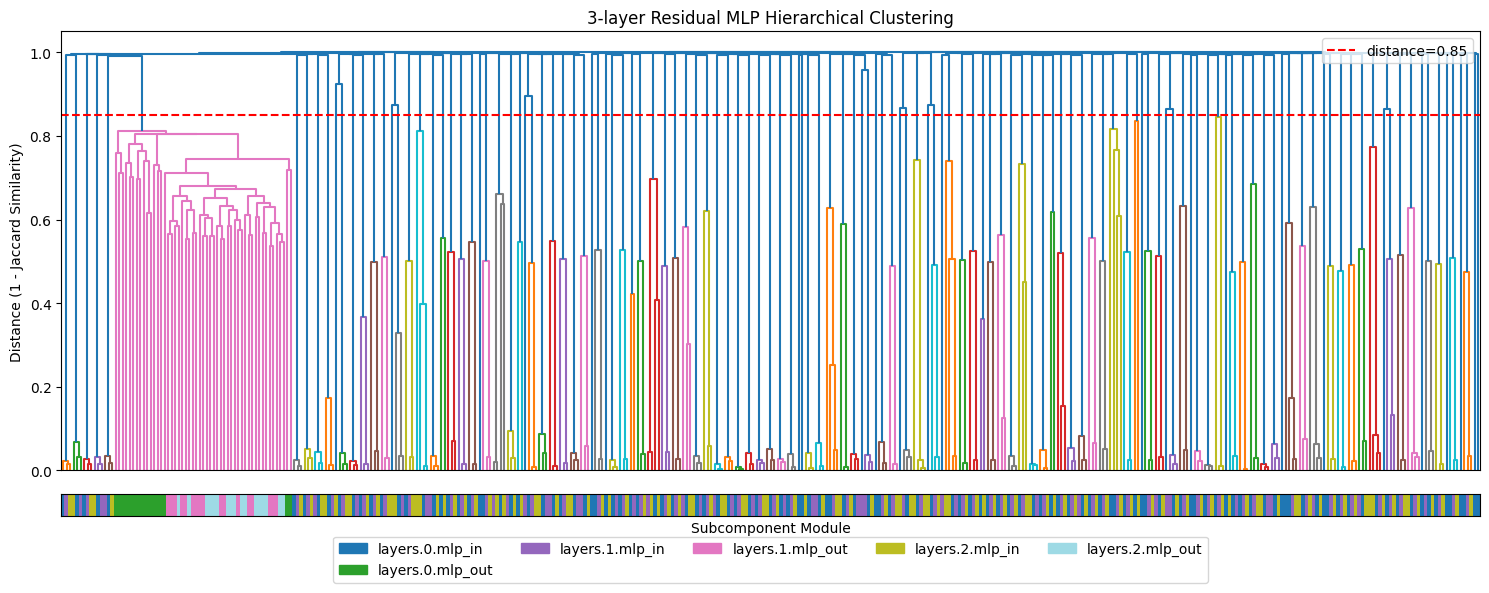

In [235]:
fig, clusters, Z, alive_mask = plot_clustering_from_results(
    results,
    group_key="group_0",
    linkage_method="complete",
    threshold=0.85,
    title="3-layer Residual MLP Hierarchical Clustering",
    min_alive_counts=500,
    figsize=(15, 6),
)